In [1]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

C:\Users\sujat\AppData\Local\Temp\ipykernel_29976\3034615406.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\sujat\projects\AI-Main\langgraph-tutorials\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book2.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)

In [3]:
len(docs)

2123

In [4]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [5]:
len(chunks)

6399

In [7]:
# 3) Index (fresh collection each run)
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1256.11it/s]


In [8]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [9]:
# 4) LLM + prompt
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

In [10]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [11]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [12]:

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}


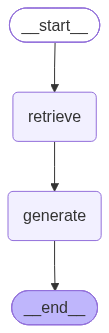

In [13]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [14]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

I don't know.


In [15]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

All transformers also have a convenience method called fit_transform() 
Prepare the Data for Machine Learning Algorithms | 61
 D o w n l o a d   f r o m   f i n e l y b o o k   w w w . f i n e l y b o o k . c o m
****************************************************************************************************
9 “Stacked Convolutional Auto-Encoders for Hierarchical Feature Extraction, ” J. Masci et al. (2011).
10 “GSNs: Generative Stochastic Networks, ” G. Alain et al. (2015).
11 “Winner-Take-All Autoencoders, ” A. Makhzani and B. Frey (2015).
12 “ Adversarial Autoencoders, ” A. Makhzani et al. (2016).
Stacked convolutional autoencoders9
Autoencoders that learn to extract visual fea
tures by reconstructing images pro‐
cessed through convolutional layers.
Generative stochastic network (GSN)10
A generalization of denoising autoencoders, with the added capability to generate
data.
Winner-take-all (WTA) autoencoder11
During training, after computing the activations of all the neurons in 